In [17]:
# Imports
import probflow as pf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

sns.set_theme()

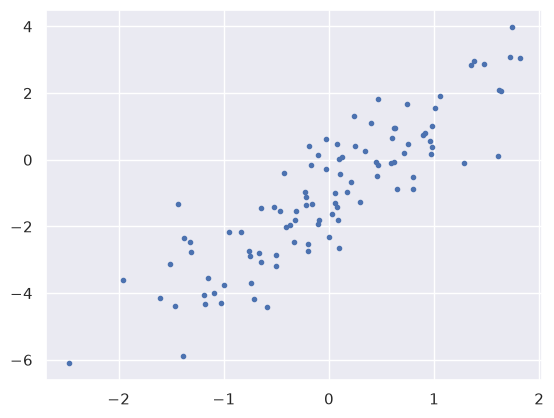

In [18]:
# Helper fn for generating data
randn = lambda *x: np.random.randn(*x).astype('float32')

# Generate some data
x = randn(100)
y = 2*x -1 + randn(100)

# Plot it
plt.plot(x, y, '.')

In [19]:
class SimpleLinearRegression(pf.ContinuousModel):

    def __init__(self):
        self.w = pf.Parameter(name='Weight')
        self.b = pf.Parameter(name='Bias')
        self.s = pf.ScaleParameter(name='Std')

    def __call__(self, x):
        return pf.Normal(x*self.w()+self.b(), self.s())

In [25]:
model = SimpleLinearRegression()
model.fit(x, y, epochs=500)

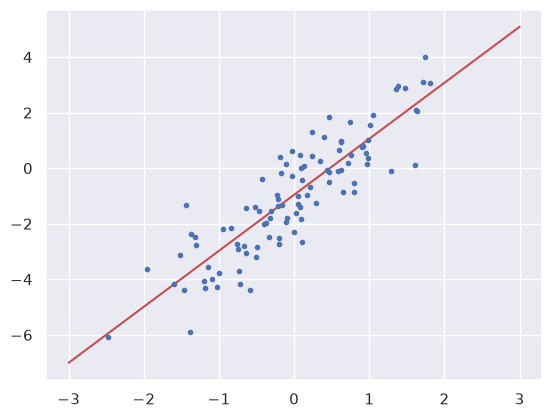

In [26]:
# Make predictions
x_test = np.array([-3, 3]).astype('float32')
preds = model.predict(x_test)

# Plot em
plt.plot(x_test, preds, 'r')
plt.plot(x, y, '.')

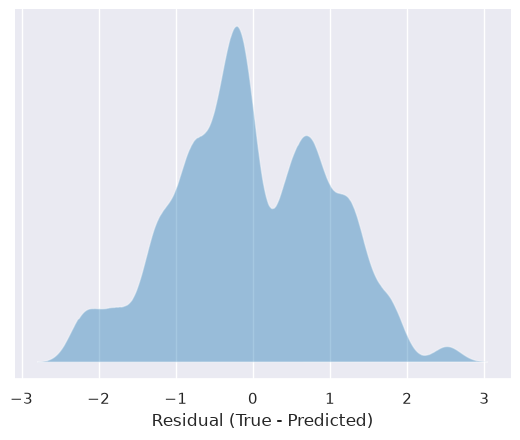

In [27]:
model.residuals_plot(x, y)

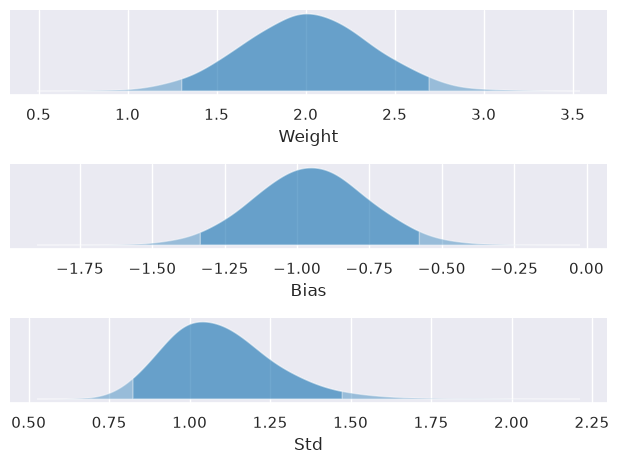

In [28]:
model.posterior_plot(ci=0.95)

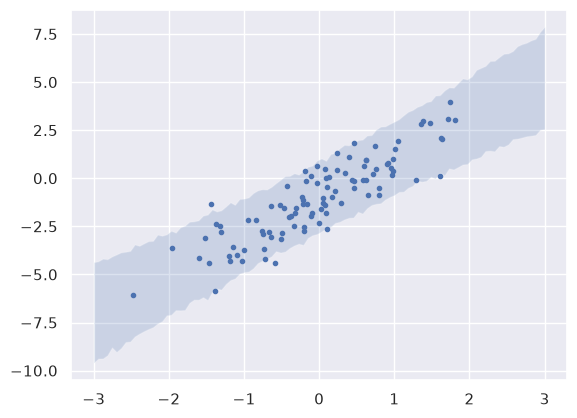

In [29]:
# Compute 95% predictive confidence intervals
x_eval = np.linspace(-3, 3, 100).astype('float32')
lb, ub = model.predictive_interval(x_eval, ci=0.9)

# Plot em
plt.fill_between(x_eval, lb, ub, alpha=0.2)
plt.plot(x, y, '.')

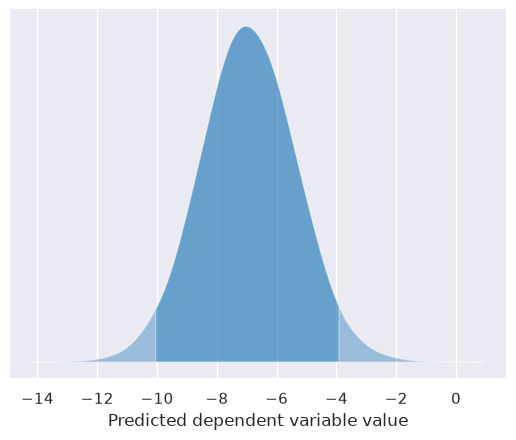

In [30]:
model.pred_dist_plot(x_eval[:1], ci=0.95)

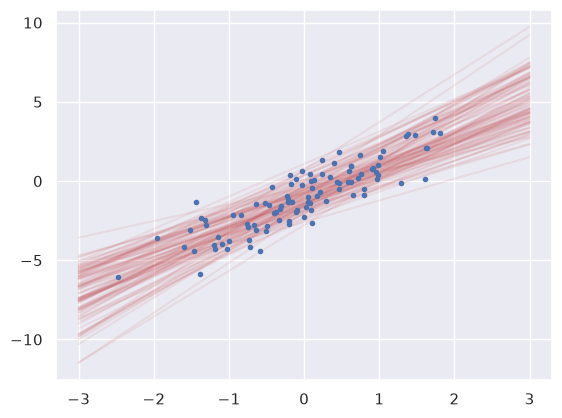

In [31]:
# Draw sample fits from the model
x_eval = np.array([-3, 3]).astype('float32')
samples = model.predictive_sample(x_eval, n=100)

# Plot em
x_plot = np.broadcast_to(x_eval[:, np.newaxis], samples.T.shape)
plt.plot(x_plot, samples.T, 'r', alpha=0.1)
plt.plot(x, y, '.')

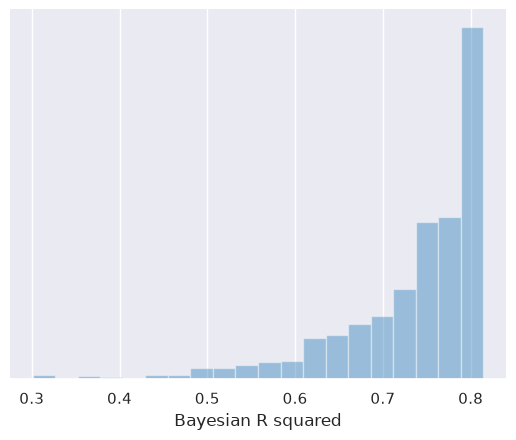

In [32]:
model.r_squared_plot(x, y)